# Entrenamiento axial final por split de paciente

Notebook reproducible para preparar el entrenamiento final del modelo axial `axial_t2_alkafri`.
Por seguridad inicia con `RUN_MODE = "preflight"`: valida entorno, datos, labels, split, duplicados y forward sin entrenar.

No publica artifacts, no reemplaza el baseline axial historico, no accede a recursos cloud y no constituye validacion clinica.


## Modos

- `preflight`: no entrena; valida entorno, paths, inventario, imagenes, mascaras, labels y split.
- `smoke`: subconjunto pequeno deterministico, maximo dos epochs, artifacts con `smoke_only=true`.
- `full`: split completo, seleccion por validation, test held-out una sola vez y paquete local candidato/final.


In [1]:
import importlib.util
import os
import subprocess
import sys

PFI_INSTALL_NOTEBOOK_DEPS = os.getenv("PFI_INSTALL_NOTEBOOK_DEPS", "1") == "1"
REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "PIL": "pillow",
    "pydicom": "pydicom",
    "SimpleITK": "SimpleITK",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "nibabel": "nibabel",
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing and PFI_INSTALL_NOTEBOOK_DEPS:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
elif missing:
    raise RuntimeError(f"Dependencias faltantes: {missing}")


In [2]:
# Montaje idempotente de Google Drive para Colab. No hace nada en entorno local/VM.
from pathlib import Path as _Path

_PREFI_USE_GOOGLE_DRIVE = os.getenv("PFI_USE_GOOGLE_DRIVE", "1").strip().lower() in {"1", "true", "yes", "on"}
_IS_COLAB = importlib.util.find_spec("google.colab") is not None
_MYDRIVE = _Path("/content/drive/MyDrive")
if _IS_COLAB and _PREFI_USE_GOOGLE_DRIVE and not _MYDRIVE.exists():
    from google.colab import drive

    mount_root = _Path("/content/drive")
    mount_root.mkdir(parents=True, exist_ok=True)
    drive.mount(str(mount_root), force_remount=False)
elif _IS_COLAB and _PREFI_USE_GOOGLE_DRIVE:
    print("Google Drive ya disponible; no se remonta.")
else:
    print("Google Drive mount omitido: entorno no Colab o PFI_USE_GOOGLE_DRIVE=False.")


Mounted at /content/drive


In [3]:
from __future__ import annotations

import csv
import dataclasses
import hashlib
import json
import math
import os
import platform
import random
import re
import subprocess
import sys
import tempfile
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset

try:
    import pydicom
except Exception:
    pydicom = None
try:
    import SimpleITK as sitk
except Exception:
    sitk = None
try:
    import nibabel as nib
except Exception:
    nib = None


## Configuracion central


In [13]:
from pathlib import Path
import os
import subprocess

REPO_ROOT = Path("/content/PFI_MVPTest_Enzo_AImodule")
COMMIT_SHA = "285159982832abb604a176b4302ac83a837ff1c9"

if not (REPO_ROOT / ".git").exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/EnzoAA004/PFI_MVPTest_Enzo_AImodule.git",
            str(REPO_ROOT),
        ],
        check=True,
    )

subprocess.run(
    ["git", "-C", str(REPO_ROOT), "fetch", "origin"],
    check=True,
)

subprocess.run(
    ["git", "-C", str(REPO_ROOT), "checkout", COMMIT_SHA],
    check=True,
)

os.environ["PFI_REPO_ROOT"] = str(REPO_ROOT)

expected_file = (
    REPO_ROOT
    / "ai_service"
    / "pfi_ai_service"
    / "model_architectures.py"
)

if not expected_file.exists():
    raise FileNotFoundError(
        f"No se encontró el módulo esperado: {expected_file}"
    )

print("Repositorio:", REPO_ROOT)
print("Commit:", COMMIT_SHA)
print("Módulo encontrado:", expected_file)

Repositorio: /content/PFI_MVPTest_Enzo_AImodule
Commit: 285159982832abb604a176b4302ac83a837ff1c9
Módulo encontrado: /content/PFI_MVPTest_Enzo_AImodule/ai_service/pfi_ai_service/model_architectures.py


In [14]:
import importlib
import sys
from pathlib import Path

AI_SERVICE_ROOT = CFG.REPO_ROOT / "ai_service"
PACKAGE_ROOT = AI_SERVICE_ROOT / "pfi_ai_service"
MODEL_ARCHITECTURES_FILE = PACKAGE_ROOT / "model_architectures.py"

print("CFG.REPO_ROOT:", CFG.REPO_ROOT)
print("AI_SERVICE_ROOT:", AI_SERVICE_ROOT)
print("Archivo esperado:", MODEL_ARCHITECTURES_FILE)

if not CFG.REPO_ROOT.exists():
    raise FileNotFoundError(
        f"CFG.REPO_ROOT no existe: {CFG.REPO_ROOT}. "
        "Ejecutá primero la celda que clona el repositorio."
    )

if not MODEL_ARCHITECTURES_FILE.exists():
    raise FileNotFoundError(
        f"No se encontró model_architectures.py en: "
        f"{MODEL_ARCHITECTURES_FILE}"
    )

ai_service_path = str(AI_SERVICE_ROOT)

if ai_service_path not in sys.path:
    sys.path.insert(0, ai_service_path)

importlib.invalidate_caches()

from pfi_ai_service.model_architectures import (
    AxialUNet2D,
    build_checkpoint_model,
    checkpoint_state_dict,
)


def build_model() -> nn.Module:
    return AxialUNet2D(
        num_classes=CFG.NUM_CLASSES,
        base_channels=CFG.BASE_CHANNELS,
    )


def strict_runtime_artifact_smoke(path: Path) -> list[int]:
    checkpoint = torch.load(
        str(path),
        map_location="cpu",
        weights_only=False,
    )

    model, _metadata = build_checkpoint_model(
        MODEL_KEY,
        checkpoint,
    )

    model.eval()

    with torch.inference_mode():
        output = model(
            torch.randn(1, 1, *CFG.TARGET_SIZE)
        )

    expected = [
        1,
        CFG.NUM_CLASSES,
        *CFG.TARGET_SIZE,
    ]

    if list(output.shape) != expected:
        raise ValueError(
            f"Shape runtime inválida: {list(output.shape)}; "
            f"esperada: {expected}"
        )

    if not torch.isfinite(output).all():
        raise ValueError(
            "El output del runtime contiene NaN o Inf"
        )

    return list(output.shape)


print("Import de pfi_ai_service: OK")

CFG.REPO_ROOT: /content/PFI_MVPTest_Enzo_AImodule
AI_SERVICE_ROOT: /content/PFI_MVPTest_Enzo_AImodule/ai_service
Archivo esperado: /content/PFI_MVPTest_Enzo_AImodule/ai_service/pfi_ai_service/model_architectures.py
Import de pfi_ai_service: OK


In [15]:
model = build_model()
test_input = torch.randn(1, 1, *CFG.TARGET_SIZE)

with torch.inference_mode():
    test_output = model(test_input)

print("Input:", list(test_input.shape))
print("Output:", list(test_output.shape))

assert list(test_output.shape) == [1, 6, 256, 256]

print("Forward axial: OK")

Input: [1, 1, 256, 256]
Output: [1, 6, 256, 256]
Forward axial: OK


In [16]:
def env_bool(name: str, default: bool) -> bool:
    raw = os.getenv(name)
    return default if raw is None else raw.strip().lower() in {"1", "true", "yes", "on"}


def utc_now() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


PFI_CLOUD_MODE = env_bool("PFI_CLOUD_MODE", False)
PFI_USE_GOOGLE_DRIVE = env_bool("PFI_USE_GOOGLE_DRIVE", True)
PFI_SYNC_DRY_RUN = env_bool("PFI_SYNC_DRY_RUN", True)
DRIVE_ROOT = Path(os.getenv("PFI_DRIVE_ROOT", "/content/drive/MyDrive/PFI_MVP"))
EXTERNAL_ROOT = DRIVE_ROOT if PFI_USE_GOOGLE_DRIVE else Path(os.getenv("PFI_LOCAL_EXTERNAL_ROOT", "/tmp/pfi_mvp"))


@dataclass(frozen=True)
class TrainConfig:
    RUN_MODE: Literal["preflight", "smoke", "full"] = os.getenv("RUN_MODE", "preflight")
    SEED: int = int(os.getenv("PFI_SEED", "2026"))
    RUN_ID: str = os.getenv("PFI_RUN_ID", "axial-final-" + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S"))
    REPO_ROOT: Path = Path(os.getenv("PFI_REPO_ROOT", "/content/PFI_MVPTest_Enzo_AImodule"))
    DATASET_ROOT: Path = Path(os.getenv("PFI_DATASET_ROOT", str(EXTERNAL_ROOT / "data" / "AXIAL_ALKAFRI")))
    IMAGES_ROOT: Path = Path(os.getenv("AXIAL_IMAGES_DIR", str(EXTERNAL_ROOT / "data" / "AXIAL_ALKAFRI")))
    MASKS_ROOT: Path = Path(os.getenv("AXIAL_MASKS_DIR", str(EXTERNAL_ROOT / "data" / "AXIAL_ALKAFRI")))
    SPLIT_MANIFEST_PATH: Path = Path(os.getenv("AXIAL_E9_CURATED_SPLIT_CSV", str(EXTERNAL_ROOT / "results" / "E9_alkafri_axial_t2_final_labels_baseline" / "E9_t2_final_labels_curated_split.csv")))
    OUTPUT_ROOT: Path = Path(os.getenv("PFI_OUTPUT_ROOT", str(EXTERNAL_ROOT / "outputs" / "axial_final_training")))
    RESUME_ROOT: Path = Path(os.getenv("PFI_RESUME_ROOT", str(EXTERNAL_ROOT / "outputs" / "axial_final_training" / "resume")))
    TARGET_SIZE: tuple[int, int] = (256, 256)
    NUM_CLASSES: int = 6
    BASE_CHANNELS: int = int(os.getenv("PFI_BASE_CHANNELS", "16"))
    BATCH_SIZE: int = int(os.getenv("PFI_BATCH_SIZE", "8"))
    NUM_WORKERS: int = int(os.getenv("PFI_NUM_WORKERS", "0"))
    MAX_EPOCHS: int = int(os.getenv("PFI_MAX_EPOCHS", "80"))
    EARLY_STOPPING_PATIENCE: int = int(os.getenv("PFI_EARLY_STOP_PATIENCE", "12"))
    LEARNING_RATE: float = float(os.getenv("PFI_LR", "0.0008"))
    WEIGHT_DECAY: float = float(os.getenv("PFI_WEIGHT_DECAY", "0.0001"))
    USE_AMP: bool = env_bool("PFI_USE_AMP", True)
    GRADIENT_CLIP_NORM: float = float(os.getenv("PFI_GRADIENT_CLIP_NORM", "1.0"))
    CHECKPOINT_EVERY_EPOCH: bool = env_bool("PFI_CHECKPOINT_EVERY_EPOCH", True)
    ALLOW_SPLIT_GENERATION: bool = env_bool("ALLOW_SPLIT_GENERATION", False)
    ENABLE_TRAIN_AUGMENTATION: bool = env_bool("ENABLE_TRAIN_AUGMENTATION", True)
    ENABLE_SPATIAL_AUGMENTATION: bool = env_bool("ENABLE_SPATIAL_AUGMENTATION", False)
    ENABLE_HORIZONTAL_FLIP: bool = env_bool("ENABLE_HORIZONTAL_FLIP", False)
    QUALITY_GATE_DICE_MACRO_FOREGROUND: float = float(os.getenv("QUALITY_GATE_DICE_MACRO_FOREGROUND", "0.70"))
    QUALITY_GATE_REQUIRE_PATIENT_HELDOUT: bool = True
    QUALITY_GATE_REQUIRE_RAW0_REPORT: bool = True
    QUALITY_GATE_REQUIRE_IOU: bool = True
    RESUME_MODE: Literal["off", "auto", "required"] = os.getenv("RESUME_MODE", "auto")
    AXIAL_IMAGE_COL: str = os.getenv("AXIAL_IMAGE_COL", "image_file_path")
    AXIAL_MASK_COL: str = os.getenv("AXIAL_MASK_COL", "final_label_file_path")
    AXIAL_PATIENT_COL: str = os.getenv("AXIAL_PATIENT_COL", "case_id_norm")
    AXIAL_SPLIT_COL: str = os.getenv("AXIAL_SPLIT_COL", "split")
    AXIAL_STUDY_COL: str = os.getenv("AXIAL_STUDY_COL", "case_id_norm")
    SMOKE_MAX_RECORDS_PER_SPLIT: int = int(os.getenv("SMOKE_MAX_RECORDS_PER_SPLIT", "12"))
    WEIGHT_MAX_RECORDS: int = int(os.getenv("PFI_WEIGHT_MAX_RECORDS", "256"))
    RAW0_WEIGHT_BOOST: float = float(os.getenv("AXIAL_RAW0_WEIGHT_BOOST", "3.0"))

    def __post_init__(self):
        if self.RUN_MODE not in {"preflight", "smoke", "full"}:
            raise ValueError(f"RUN_MODE invalido: {self.RUN_MODE}")
        if self.TARGET_SIZE != (256, 256) or self.NUM_CLASSES != 6 or self.BASE_CHANNELS != 16:
            raise ValueError("Arquitectura axial final debe ser target 256, numClasses 6, baseChannels 16")


CFG = TrainConfig()
MODEL_KEY = "axial_t2_alkafri"
RAW_ALLOWED_LABELS = {0, 50, 100, 150, 200, 250}
RAW_TO_CLASS_INDEX = {250: 0, 0: 1, 50: 2, 100: 3, 150: 4, 200: 5}
CLASS_INDEX_TO_NAME = {0: "background_250", 1: "raw_0", 2: "raw_50", 3: "raw_100", 4: "raw_150", 5: "raw_200"}
FOREGROUND_CLASS_IDS = [1, 2, 3, 4, 5]
FOREGROUND_EXCLUDING_RAW0 = [2, 3, 4, 5]
humanReviewRequired = True
notClinicalDiagnosis = True
OUTPUT_DIRS = {name: CFG.OUTPUT_ROOT / CFG.RUN_ID / name for name in ["models", "manifests", "metrics", "figures", "predictions", "logs", "reports"]}
RESUME_DIR = CFG.RESUME_ROOT / CFG.RUN_ID
print(json.dumps(dataclasses.asdict(CFG), indent=2, default=str))


PREPROCESSING_CONFIG = {
    "normalization": "robust_percentile_1_99_per_image_train_independent",
    "imageResize": "bilinear",
    "maskResize": "nearest",
    "rawToClassIndex": RAW_TO_CLASS_INDEX,
    "augmentations": {
        "enabled": CFG.ENABLE_TRAIN_AUGMENTATION,
        "spatialEnabledByDefault": False,
        "horizontalFlip": {"enabled": CFG.ENABLE_HORIZONTAL_FLIP, "p": 0.5, "note": "requiere validar lateralidad antes de habilitar"},
        "smallRotationDegrees": {"enabled": False, "maxAbsDegrees": 5, "imageInterpolation": "bilinear", "maskInterpolation": "nearest"},
        "intensityJitter": {"enabled": True, "p": 0.25, "scale": [0.95, 1.05], "shift": [-0.03, 0.03]},
    },
}


{
  "RUN_MODE": "preflight",
  "SEED": 2026,
  "RUN_ID": "axial-final-20260723-114154",
  "REPO_ROOT": "/content/PFI_MVPTest_Enzo_AImodule",
  "DATASET_ROOT": "/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI",
  "IMAGES_ROOT": "/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI",
  "MASKS_ROOT": "/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI",
  "SPLIT_MANIFEST_PATH": "/content/drive/MyDrive/PFI_MVP/results/E9_alkafri_axial_t2_final_labels_baseline/E9_t2_final_labels_curated_split.csv",
  "OUTPUT_ROOT": "/content/drive/MyDrive/PFI_MVP/outputs/axial_final_training",
  "RESUME_ROOT": "/content/drive/MyDrive/PFI_MVP/outputs/axial_final_training/resume",
  "TARGET_SIZE": [
    256,
    256
  ],
  "NUM_CLASSES": 6,
  "BASE_CHANNELS": 16,
  "BATCH_SIZE": 8,
  "NUM_WORKERS": 0,
  "MAX_EPOCHS": 80,
  "EARLY_STOPPING_PATIENCE": 12,
  "LEARNING_RATE": 0.0008,
  "WEIGHT_DECAY": 0.0001,
  "USE_AMP": true,
  "GRADIENT_CLIP_NORM": 1.0,
  "CHECKPOINT_EVERY_EPOCH": true,
  "ALLOW_SPLIT_GENERATION

## Entorno y reproducibilidad


In [17]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def git_value(args: list[str]) -> str:
    try:
        return subprocess.check_output(["git", *args], cwd=str(CFG.REPO_ROOT), text=True, stderr=subprocess.DEVNULL).strip()
    except Exception:
        return "unavailable"


def environment_manifest() -> dict[str, Any]:
    cuda = torch.cuda.is_available()
    return {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cudaAvailable": cuda,
        "gpuName": torch.cuda.get_device_name(0) if cuda else None,
        "gpuVramGb": round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2) if cuda else None,
        "gitCommit": git_value(["rev-parse", "HEAD"]),
        "gitDirty": bool(git_value(["status", "--short"])),
        "PFI_CLOUD_MODE": PFI_CLOUD_MODE,
        "PFI_USE_GOOGLE_DRIVE": PFI_USE_GOOGLE_DRIVE,
        "PFI_SYNC_DRY_RUN": PFI_SYNC_DRY_RUN,
    }


set_seed(CFG.SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if CFG.RUN_MODE == "full" and DEVICE.type != "cuda":
    raise RuntimeError("RUN_MODE=full requiere CUDA para evitar una corrida final accidental en CPU")
ENV_MANIFEST = environment_manifest()
print(json.dumps(ENV_MANIFEST, indent=2))


{
  "python": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "torch": "2.11.0+cpu",
  "cudaAvailable": false,
  "gpuName": null,
  "gpuVramGb": null,
  "gitCommit": "285159982832abb604a176b4302ac83a837ff1c9",
  "gitDirty": false,
  "PFI_CLOUD_MODE": false,
  "PFI_USE_GOOGLE_DRIVE": true,
  "PFI_SYNC_DRY_RUN": true
}


## Utilidades seguras


In [18]:
def mkdirs_for_run() -> None:
    for path in [*OUTPUT_DIRS.values(), RESUME_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def sha256_stream(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as fh:
        for chunk in iter(lambda: fh.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def atomic_write_bytes(path: Path, data: bytes) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    handle, tmp_name = tempfile.mkstemp(prefix=path.name, suffix=".tmp", dir=str(path.parent))
    try:
        with os.fdopen(handle, "wb") as fh:
            fh.write(data)
            fh.flush()
            os.fsync(fh.fileno())
        Path(tmp_name).replace(path)
    except Exception:
        Path(tmp_name).unlink(missing_ok=True)
        raise


def atomic_write_json(path: Path, payload: dict[str, Any]) -> None:
    atomic_write_bytes(path, json.dumps(payload, indent=2, sort_keys=True, ensure_ascii=False).encode("utf-8"))


def atomic_write_csv(path: Path, rows: list[dict[str, Any]]) -> None:
    if not rows:
        atomic_write_bytes(path, b"")
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    handle, tmp_name = tempfile.mkstemp(prefix=path.name, suffix=".tmp", dir=str(path.parent))
    try:
        with os.fdopen(handle, "w", encoding="utf-8", newline="") as fh:
            writer = csv.DictWriter(fh, fieldnames=list(rows[0].keys()))
            writer.writeheader()
            writer.writerows(rows)
            fh.flush()
            os.fsync(fh.fileno())
        Path(tmp_name).replace(path)
    except Exception:
        Path(tmp_name).unlink(missing_ok=True)
        raise


def safe_source_name(path: str | Path) -> str:
    return Path(path).name


## Lectura, preprocesamiento y labels


In [19]:
def open_medical_array(path: Path) -> np.ndarray:
    suffixes = [s.lower() for s in path.suffixes]
    suffix = path.suffix.lower()
    if suffix == ".npy":
        return np.asarray(np.load(path))
    if suffix in {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}:
        return np.asarray(Image.open(path))
    if suffix in {".dcm", ".ima"}:
        if pydicom is None:
            raise RuntimeError("pydicom no disponible")
        return np.asarray(pydicom.dcmread(str(path)).pixel_array)
    if suffix in {".mha", ".mhd"}:
        if sitk is None:
            raise RuntimeError("SimpleITK no disponible")
        return sitk.GetArrayFromImage(sitk.ReadImage(str(path)))
    if suffix == ".nii" or suffixes[-2:] == [".nii", ".gz"]:
        if nib is None:
            raise RuntimeError("nibabel no disponible")
        return np.asarray(nib.load(str(path)).get_fdata())
    raise ValueError(f"Formato no soportado: {suffix}")


def as_2d_slice(array: np.ndarray, case_id: str) -> np.ndarray:
    arr = np.asarray(array)
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3 and 1 in arr.shape:
        return np.squeeze(arr)
    raise ValueError(f"{case_id}: shape axial no soportado {arr.shape}")


def robust_normalize(image: np.ndarray) -> np.ndarray:
    arr = np.nan_to_num(np.asarray(image, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    lo, hi = np.percentile(arr, [1.0, 99.0])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(arr.min()), float(arr.max())
    if hi <= lo:
        return np.zeros_like(arr, dtype=np.float32)
    return ((np.clip(arr, lo, hi) - lo) / (hi - lo)).astype(np.float32)


def resize_image(image: np.ndarray) -> np.ndarray:
    return np.asarray(Image.fromarray(image.astype(np.float32)).resize((CFG.TARGET_SIZE[1], CFG.TARGET_SIZE[0]), Image.Resampling.BILINEAR), dtype=np.float32)


def resize_mask(mask: np.ndarray) -> np.ndarray:
    return np.asarray(Image.fromarray(mask.astype(np.int32)).resize((CFG.TARGET_SIZE[1], CFG.TARGET_SIZE[0]), Image.Resampling.NEAREST), dtype=np.int64)


def apply_label_mapping(mask: np.ndarray, case_id: str) -> np.ndarray:
    labels = {int(v) for v in np.unique(mask)}
    unexpected = sorted(labels - RAW_ALLOWED_LABELS)
    if unexpected:
        raise ValueError(f"{case_id}: labels inesperados {unexpected}")
    mapped = np.zeros(mask.shape, dtype=np.int64)
    for raw_label, class_id in RAW_TO_CLASS_INDEX.items():
        mapped[np.asarray(mask) == raw_label] = class_id
    return mapped


## Inventario y split por paciente


In [20]:
@dataclass(frozen=True)
class AxialRecord:
    image_path: str
    mask_path: str
    patientId: str
    studyId: str
    sliceId: str
    split: str
    sourceImage: str
    sourceMask: str


def resolve_path(value: Any, bases: Iterable[Path]) -> Path:
    raw = Path(str(value))
    if raw.is_absolute() and raw.exists():
        return raw
    for base in bases:
        for candidate in [base / raw, base / raw.name]:
            if candidate.exists():
                return candidate
    return raw


def required_cell_value(row: Any, column: str, row_number: int) -> str:
    value = getattr(row, column)
    if pd.isna(value):
        raise ValueError(f"Fila {row_number}: columna requerida nula: {column}")
    text = str(value).strip()
    if not text or text.lower() == "nan":
        raise ValueError(f"Fila {row_number}: columna requerida vacia/nan: {column}")
    return text


def slice_id_from_paths(patient_id: str, image_path: Path, mask_path: Path) -> str:
    material = f"{patient_id}|{image_path.resolve()}|{mask_path.resolve()}"
    return "slice_" + hashlib.sha256(material.encode("utf-8")).hexdigest()[:16]


def build_records_from_split_manifest() -> list[AxialRecord]:
    if not CFG.SPLIT_MANIFEST_PATH.exists():
        if CFG.ALLOW_SPLIT_GENERATION:
            raise NotImplementedError("Solo se permite generar candidate split con revision humana posterior")
        raise FileNotFoundError(f"Falta split manifest E9: {CFG.SPLIT_MANIFEST_PATH}")
    df = pd.read_csv(CFG.SPLIT_MANIFEST_PATH)
    required = [CFG.AXIAL_IMAGE_COL, CFG.AXIAL_MASK_COL, CFG.AXIAL_PATIENT_COL, CFG.AXIAL_SPLIT_COL]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f"Faltan columnas: {missing}")
    bases = [CFG.DATASET_ROOT, CFG.IMAGES_ROOT, CFG.MASKS_ROOT, CFG.SPLIT_MANIFEST_PATH.parent]
    records = []
    for row_number, row in enumerate(df.itertuples(index=False), 2):
        image_value = required_cell_value(row, CFG.AXIAL_IMAGE_COL, row_number)
        mask_value = required_cell_value(row, CFG.AXIAL_MASK_COL, row_number)
        patient = required_cell_value(row, CFG.AXIAL_PATIENT_COL, row_number)
        split = required_cell_value(row, CFG.AXIAL_SPLIT_COL, row_number).lower()
        study = required_cell_value(row, CFG.AXIAL_STUDY_COL, row_number) if hasattr(row, CFG.AXIAL_STUDY_COL) else patient
        image = resolve_path(image_value, bases)
        mask = resolve_path(mask_value, bases)
        if not image.exists() or not mask.exists():
            raise FileNotFoundError(f"Archivo axial inexistente: {image.name} / {mask.name}")
        records.append(AxialRecord(str(image), str(mask), patient, study, slice_id_from_paths(patient, image, mask), split, safe_source_name(image), safe_source_name(mask)))
    return records


def save_split_snapshot(records: list[AxialRecord]) -> Path:
    snapshot_path = OUTPUT_DIRS["manifests"] / "split_snapshot.csv"
    snapshot_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame([dataclasses.asdict(r) for r in records]).to_csv(snapshot_path, index=False)
    return snapshot_path


def summarize_records(records: list[AxialRecord]) -> pd.DataFrame:
    df = pd.DataFrame([dataclasses.asdict(r) for r in records])
    return df.groupby("split").agg(n_slices=("sliceId", "count"), n_patients=("patientId", "nunique"))


In [21]:
def validate_split_integrity(records: list[AxialRecord]) -> dict[str, Any]:
    df = pd.DataFrame([dataclasses.asdict(r) for r in records])
    if df.empty:
        raise ValueError("Split manifest sin filas")
    bad = sorted(set(df["split"]) - {"train", "val", "test"})
    if bad:
        raise ValueError(f"Splits invalidos: {bad}")
    for split in ["train", "val", "test"]:
        if int((df["split"] == split).sum()) == 0:
            raise ValueError(f"Split vacio: {split}")
    duplicate_rows = int(df.duplicated(subset=["image_path", "mask_path", "patientId", "split"]).sum())
    if duplicate_rows:
        raise ValueError(f"Filas exactamente duplicadas: {duplicate_rows}")
    leakage_by_key = {}
    for key in ["patientId", "studyId", "image_path", "mask_path"]:
        leaked = df.groupby(key)["split"].nunique()
        leaked = leaked[leaked > 1]
        leakage_by_key[key] = int(len(leaked))
        if not leaked.empty:
            raise ValueError(f"Leakage cross-split en {key}: {len(leaked)}")
    missing_paths = [r.sourceImage for r in records if not Path(r.image_path).exists()]
    missing_paths += [r.sourceMask for r in records if not Path(r.mask_path).exists()]
    if missing_paths:
        raise FileNotFoundError(f"Paths faltantes: {missing_paths[:20]}")
    return {
        "patientHeldout": True,
        "leakageDetected": False,
        "duplicateRows": duplicate_rows,
        "leakageByKey": leakage_by_key,
        "splitCounts": df["split"].value_counts().to_dict(),
        "patientsBySplit": df.groupby("split")["patientId"].nunique().to_dict(),
        "imagesBySplit": df.groupby("split")["image_path"].nunique().to_dict(),
    }


def scan_labels_and_shapes(records: list[AxialRecord]) -> dict[str, Any]:
    pixel_counts: dict[str, Counter[int]] = defaultdict(Counter)
    case_presence: dict[str, Counter[int]] = defaultdict(Counter)
    raw0_by_split: dict[str, set[str]] = defaultdict(set)
    formats: Counter[str] = Counter()
    dimensions: Counter[str] = Counter()
    for index, record in enumerate(records, 1):
        image = as_2d_slice(open_medical_array(Path(record.image_path)), record.sliceId)
        mask = as_2d_slice(open_medical_array(Path(record.mask_path)), record.sliceId)
        if image.shape != mask.shape:
            raise ValueError(f"{record.sliceId}: image/mask shape mismatch {image.shape} != {mask.shape}")
        labels = {int(v) for v in np.unique(mask)}
        unexpected = sorted(labels - RAW_ALLOWED_LABELS)
        if unexpected:
            raise ValueError(f"{record.sliceId}: labels inesperados {unexpected}")
        mapped = apply_label_mapping(mask, record.sliceId)
        bincount = np.bincount(mapped.reshape(-1), minlength=CFG.NUM_CLASSES)
        for class_id, count in enumerate(bincount):
            pixel_counts[record.split][class_id] += int(count)
            if count > 0:
                case_presence[record.split][class_id] += 1
        if bincount[1] > 0:
            raw0_by_split[record.split].add(record.patientId)
        formats[Path(record.image_path).suffix.lower()] += 1
        dimensions[str(tuple(image.shape))] += 1
        if index % 250 == 0:
            print(f"scan {index}/{len(records)}")
    absent_train = [CLASS_INDEX_TO_NAME[i] for i in range(CFG.NUM_CLASSES) if case_presence.get("train", Counter()).get(i, 0) == 0]
    if absent_train:
        raise ValueError(f"Clases ausentes en train: {absent_train}")
    warnings_by_split = []
    for split in ["val", "test"]:
        absent = [CLASS_INDEX_TO_NAME[i] for i in range(CFG.NUM_CLASSES) if case_presence.get(split, Counter()).get(i, 0) == 0]
        if absent:
            message = f"WARNING: clases ausentes en {split}: {absent}"
            warnings.warn(message)
            warnings_by_split.append(message)
    return {
        "pixelCountsBySplit": {s: {CLASS_INDEX_TO_NAME[k]: int(v) for k, v in c.items()} for s, c in pixel_counts.items()},
        "casePresenceBySplit": {s: {CLASS_INDEX_TO_NAME[k]: int(v) for k, v in c.items()} for s, c in case_presence.items()},
        "raw0PatientsBySplit": {s: len(v) for s, v in raw0_by_split.items()},
        "formats": dict(formats),
        "dimensions": dict(dimensions),
        "warnings": warnings_by_split,
    }


## Duplicados y leakage por hash


In [22]:
def compute_duplicate_report(records: list[AxialRecord], full_hash: bool = True) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for record in records:
        for kind, raw_path in [("image", record.image_path), ("mask", record.mask_path)]:
            path = Path(raw_path)
            rows.append({
                "kind": kind,
                "fileSize": int(path.stat().st_size),
                "sha256": None,
                "patientId": record.patientId,
                "split": record.split,
                "sliceId": record.sliceId,
                "source": safe_source_name(path),
                "resolvedPath": str(path.resolve()),
            })
    df = pd.DataFrame(rows)
    repeated_size = df.groupby(["kind", "fileSize"])["resolvedPath"].transform("count") > 1
    if full_hash:
        repeated_size = pd.Series([True] * len(df), index=df.index)
    for idx in df[repeated_size].index:
        df.at[idx, "sha256"] = sha256_stream(Path(df.at[idx, "resolvedPath"]))
    return df


def _hash_group_summary(group: pd.DataFrame) -> dict[str, Any]:
    return {
        "sha256": str(group["sha256"].iloc[0]),
        "fileSize": int(group["fileSize"].iloc[0]),
        "splitCount": int(group["split"].nunique()),
        "patientCount": int(group["patientId"].nunique()),
        "splits": sorted(group["split"].astype(str).unique().tolist()),
        "patientIds": sorted(group["patientId"].astype(str).unique().tolist()),
        "sliceIds": sorted(group["sliceId"].astype(str).unique().tolist())[:20],
        "sources": group["source"].head(20).tolist(),
    }


def validate_no_duplicate_leakage(duplicate_df: pd.DataFrame) -> dict[str, Any]:
    duplicate_images: list[dict[str, Any]] = []
    duplicate_pairs: list[dict[str, Any]] = []
    repeated_masks: list[dict[str, Any]] = []
    mask_only_warnings: list[str] = []
    hashed_df = duplicate_df.dropna(subset=["sha256"]).copy()

    images = hashed_df[hashed_df["kind"] == "image"]
    for _digest, group in images.groupby("sha256"):
        if len(group) <= 1:
            continue
        summary = _hash_group_summary(group)
        if summary["splitCount"] > 1 or summary["patientCount"] > 1:
            duplicate_images.append(summary)

    pivot = hashed_df.pivot_table(
        index=["sliceId", "patientId", "split"],
        columns="kind",
        values="sha256",
        aggfunc="first",
    ).reset_index()
    if {"image", "mask"}.issubset(pivot.columns):
        pairs = pivot.dropna(subset=["image", "mask"]).rename(columns={"image": "imageSha256", "mask": "maskSha256"})
        pair_sizes = duplicate_df.pivot_table(index="sliceId", columns="kind", values="fileSize", aggfunc="first").reset_index().rename(columns={"image": "imageFileSize", "mask": "maskFileSize"})
        pairs = pairs.merge(pair_sizes, on="sliceId", how="left")
        for (image_sha, mask_sha), group in pairs.groupby(["imageSha256", "maskSha256"]):
            if len(group) <= 1:
                continue
            split_count = int(group["split"].nunique())
            patient_count = int(group["patientId"].nunique())
            if split_count > 1 or patient_count > 1:
                duplicate_pairs.append({
                    "imageSha256": str(image_sha),
                    "maskSha256": str(mask_sha),
                    "imageFileSize": int(group["imageFileSize"].iloc[0]),
                    "maskFileSize": int(group["maskFileSize"].iloc[0]),
                    "splitCount": split_count,
                    "patientCount": patient_count,
                    "splits": sorted(group["split"].astype(str).unique().tolist()),
                    "patientIds": sorted(group["patientId"].astype(str).unique().tolist()),
                    "sliceIds": sorted(group["sliceId"].astype(str).unique().tolist())[:20],
                })

        for mask_sha, group in pairs.groupby("maskSha256"):
            if len(group) <= 1:
                continue
            image_count = int(group["imageSha256"].nunique())
            if image_count > 1:
                warning = {
                    "maskSha256": str(mask_sha),
                    "imageSha256Count": image_count,
                    "splitCount": int(group["split"].nunique()),
                    "patientCount": int(group["patientId"].nunique()),
                    "splits": sorted(group["split"].astype(str).unique().tolist()),
                    "patientIds": sorted(group["patientId"].astype(str).unique().tolist()),
                    "sliceIds": sorted(group["sliceId"].astype(str).unique().tolist())[:20],
                }
                repeated_masks.append(warning)
                mask_only_warnings.append(f"WARNING: misma mascara SHA-256 asociada a imagenes diferentes: {mask_sha}")

    if duplicate_images or duplicate_pairs:
        raise ValueError(f"Duplicados/leakage por contenido real: images={duplicate_images[:10]} pairs={duplicate_pairs[:10]}")
    for message in mask_only_warnings:
        warnings.warn(message)
    duplicate_df.to_csv(OUTPUT_DIRS["metrics"] / "duplicate_report.csv", index=False)
    report = {
        "duplicateLeakage": False,
        "checkedRows": int(len(duplicate_df)),
        "hashedRows": int(duplicate_df["sha256"].notna().sum()),
        "sameSizeRows": int(duplicate_df.groupby(["kind", "fileSize"])["resolvedPath"].transform("count").gt(1).sum()),
        "duplicateImages": duplicate_images,
        "duplicatePairs": duplicate_pairs,
        "repeatedMasks": repeated_masks,
        "maskOnlyWarnings": mask_only_warnings,
    }
    atomic_write_json(OUTPUT_DIRS["metrics"] / "duplicate_hash_report.json", report)
    return report


## Dataset, DataLoader y sanity check


In [23]:
AUGMENTATION_EPOCH = 0


def set_augmentation_epoch(epoch: int) -> None:
    global AUGMENTATION_EPOCH
    AUGMENTATION_EPOCH = int(epoch)


def maybe_augment(image: np.ndarray, mask: np.ndarray, rng: random.Random) -> tuple[np.ndarray, np.ndarray]:
    if not CFG.ENABLE_TRAIN_AUGMENTATION:
        return image, mask
    if CFG.ENABLE_SPATIAL_AUGMENTATION and CFG.ENABLE_HORIZONTAL_FLIP and rng.random() < 0.5:
        image, mask = np.flip(image, 1).copy(), np.flip(mask, 1).copy()
    if rng.random() < 0.25:
        image = np.clip(image * rng.uniform(0.95, 1.05) + rng.uniform(-0.03, 0.03), 0, 1).astype(np.float32)
    return image, mask


class AxialSegmentationDataset(Dataset):
    def __init__(self, records: list[AxialRecord], split: str, augment: bool):
        self.records = [r for r in records if r.split == split]
        self.augment = augment
        if not self.records:
            raise ValueError(f"Dataset vacio: {split}")

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int) -> dict[str, Any]:
        record = self.records[index]
        image = resize_image(robust_normalize(as_2d_slice(open_medical_array(Path(record.image_path)), record.sliceId)))
        mask = apply_label_mapping(resize_mask(as_2d_slice(open_medical_array(Path(record.mask_path)), record.sliceId)), record.sliceId)
        if self.augment:
            seed_material = f"{CFG.SEED}|{AUGMENTATION_EPOCH}|{index}|{record.sliceId}"
            seed = int(hashlib.sha256(seed_material.encode("utf-8")).hexdigest()[:8], 16)
            image, mask = maybe_augment(image, mask, random.Random(seed))
        return {"image": torch.from_numpy(image[None].astype(np.float32)), "mask": torch.from_numpy(mask.astype(np.int64)), "patientId": record.patientId, "studyId": record.studyId, "sliceId": record.sliceId, "sourceImage": record.sourceImage, "sourceMask": record.sourceMask}


def limit_records_for_smoke(records: list[AxialRecord]) -> list[AxialRecord]:
    selected: list[AxialRecord] = []
    for split in ["train", "val", "test"]:
        split_records = [r for r in records if r.split == split]
        by_patient: dict[str, list[AxialRecord]] = defaultdict(list)
        for record in split_records:
            by_patient[record.patientId].append(record)
        patient_ids = sorted(by_patient)[: max(2, min(2, len(by_patient)))]
        for patient_id in patient_ids:
            selected.extend(by_patient[patient_id][: max(1, CFG.SMOKE_MAX_RECORDS_PER_SPLIT // max(len(patient_ids), 1))])
    summary = pd.DataFrame([dataclasses.asdict(r) for r in selected])
    if not summary.empty:
        print("smoke selection", summary.groupby("split").agg(patients=("patientId", "nunique"), slices=("sliceId", "count")).to_dict())
    return selected


def seed_worker(worker_id: int) -> None:
    random.seed(CFG.SEED + worker_id)
    np.random.seed(CFG.SEED + worker_id)


def build_loaders(records: list[AxialRecord], smoke: bool) -> dict[str, DataLoader]:
    if smoke:
        records = limit_records_for_smoke(records)
    generator = torch.Generator().manual_seed(CFG.SEED)
    return {split: DataLoader(AxialSegmentationDataset(records, split, split == "train"), batch_size=CFG.BATCH_SIZE, shuffle=split == "train", num_workers=CFG.NUM_WORKERS, worker_init_fn=seed_worker, generator=generator, pin_memory=DEVICE.type == "cuda", persistent_workers=CFG.NUM_WORKERS > 0, drop_last=False) for split in ["train", "val", "test"]}


## Arquitectura AxialUNet2D compatible con runtime


In [24]:
sys.path.insert(0, str(CFG.REPO_ROOT / "ai_service"))
from pfi_ai_service.model_architectures import AxialUNet2D, build_checkpoint_model, checkpoint_state_dict


def build_model() -> nn.Module:
    return AxialUNet2D(num_classes=CFG.NUM_CLASSES, base_channels=CFG.BASE_CHANNELS)


def strict_runtime_artifact_smoke(path: Path) -> list[int]:
    checkpoint = torch.load(str(path), map_location="cpu", weights_only=False)
    model, _metadata = build_checkpoint_model(MODEL_KEY, checkpoint)
    model.eval()
    with torch.inference_mode():
        output = model(torch.randn(1, 1, *CFG.TARGET_SIZE))
    expected = [1, CFG.NUM_CLASSES, *CFG.TARGET_SIZE]
    if list(output.shape) != expected:
        raise ValueError(f"Shape runtime invalida: {list(output.shape)}")
    return list(output.shape)


## Loss y metricas Dice/IoU


In [25]:
def class_weight_report(records: list[AxialRecord]) -> dict[str, Any]:
    counts = np.ones(CFG.NUM_CLASSES, dtype=np.float64)
    image_presence = np.zeros(CFG.NUM_CLASSES, dtype=np.int64)
    train_records = [r for r in records if r.split == "train"][: CFG.WEIGHT_MAX_RECORDS]
    for record in train_records:
        mapped = apply_label_mapping(resize_mask(as_2d_slice(open_medical_array(Path(record.mask_path)), record.sliceId)), record.sliceId)
        bincount = np.bincount(mapped.reshape(-1), minlength=CFG.NUM_CLASSES)
        counts += bincount
        image_presence += (bincount > 0).astype(np.int64)
    freq = counts / counts.sum()
    base = 1.0 / np.sqrt(freq)
    base = base / base.mean()
    boosted = base.copy()
    boosted[1] *= CFG.RAW0_WEIGHT_BOOST
    final = np.clip(boosted, 0.25, 8.0)
    final = final / final.mean()
    ratio = float(final.max() / max(final.min(), 1e-8))
    if ratio > 12:
        warnings.warn(f"WARNING: class weight max/min desproporcionado: {ratio:.2f}")
    return {
        "trainSamplesUsed": len(train_records),
        "pixelCounts": {CLASS_INDEX_TO_NAME[i]: int(counts[i]) for i in range(CFG.NUM_CLASSES)},
        "imagePresence": {CLASS_INDEX_TO_NAME[i]: int(image_presence[i]) for i in range(CFG.NUM_CLASSES)},
        "baseWeights": {CLASS_INDEX_TO_NAME[i]: float(base[i]) for i in range(CFG.NUM_CLASSES)},
        "raw0Boost": CFG.RAW0_WEIGHT_BOOST,
        "finalWeights": {CLASS_INDEX_TO_NAME[i]: float(final[i]) for i in range(CFG.NUM_CLASSES)},
        "maxMinRatio": ratio,
    }


def estimate_class_weights(records: list[AxialRecord]) -> torch.Tensor:
    report = class_weight_report(records)
    return torch.tensor([report["finalWeights"][CLASS_INDEX_TO_NAME[i]] for i in range(CFG.NUM_CLASSES)], dtype=torch.float32)


def soft_dice_loss(logits: torch.Tensor, target: torch.Tensor, include_background: bool = False, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.softmax(logits, dim=1)
    one_hot = F.one_hot(target, CFG.NUM_CLASSES).permute(0, 3, 1, 2).float()
    class_ids = range(CFG.NUM_CLASSES) if include_background else FOREGROUND_CLASS_IDS
    losses = []
    for class_id in class_ids:
        p, t = probs[:, class_id], one_hot[:, class_id]
        losses.append(1 - ((2 * (p * t).sum((1, 2)) + eps) / (p.sum((1, 2)) + t.sum((1, 2)) + eps)))
    return torch.stack(losses).mean()


def multiclass_loss(logits: torch.Tensor, target: torch.Tensor, ce: nn.Module) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    ce_loss = ce(logits, target)
    dice_loss_value = soft_dice_loss(logits, target)
    return ce_loss + dice_loss_value, ce_loss, dice_loss_value


def dice_iou_for_class(pred: np.ndarray, truth: np.ndarray, class_id: int) -> tuple[float | None, float | None, int, int, int]:
    pred_mask, truth_mask = pred == class_id, truth == class_id
    tp = int(np.logical_and(pred_mask, truth_mask).sum())
    fp = int(np.logical_and(pred_mask, ~truth_mask).sum())
    fn = int(np.logical_and(~pred_mask, truth_mask).sum())
    dice_den, iou_den = 2 * tp + fp + fn, tp + fp + fn
    # Si GT y pred no tienen la clase, la metrica queda indefinida y se excluye del macro.
    return (None if dice_den == 0 else 2 * tp / dice_den, None if iou_den == 0 else tp / iou_den, int(truth_mask.any()), int(pred_mask.any()), int(not truth_mask.any()))


def metrics_from_predictions(pred: np.ndarray, truth: np.ndarray) -> dict[str, Any]:
    per_class = {}
    confusion = np.zeros((CFG.NUM_CLASSES, CFG.NUM_CLASSES), dtype=np.int64)
    for p, t in zip(pred, truth):
        valid = (t >= 0) & (t < CFG.NUM_CLASSES)
        confusion += np.bincount(CFG.NUM_CLASSES * t[valid].reshape(-1) + p[valid].reshape(-1), minlength=CFG.NUM_CLASSES**2).reshape(CFG.NUM_CLASSES, CFG.NUM_CLASSES)
    for class_id, name in CLASS_INDEX_TO_NAME.items():
        values = [dice_iou_for_class(p, t, class_id) for p, t in zip(pred, truth)]
        dice = [v[0] for v in values if v[0] is not None]
        iou = [v[1] for v in values if v[1] is not None]
        per_class[name] = {
            "dice": float(np.mean(dice)) if dice else None,
            "iou": float(np.mean(iou)) if iou else None,
            "evaluable_cases": len(dice),
            "gt_present_cases": sum(v[2] for v in values),
            "pred_present_cases": sum(v[3] for v in values),
            "gt_absent_cases": sum(v[4] for v in values),
        }
    def macro(class_ids: list[int], metric: str) -> float | None:
        vals = [per_class[CLASS_INDEX_TO_NAME[c]][metric] for c in class_ids if per_class[CLASS_INDEX_TO_NAME[c]][metric] is not None]
        return float(np.mean(vals)) if vals else None
    return {
        "perClass": per_class,
        "dice_macro_foreground": macro(FOREGROUND_CLASS_IDS, "dice"),
        "iou_macro_foreground": macro(FOREGROUND_CLASS_IDS, "iou"),
        "dice_macro_excluding_raw0": macro(FOREGROUND_EXCLUDING_RAW0, "dice"),
        "iou_macro_excluding_raw0": macro(FOREGROUND_EXCLUDING_RAW0, "iou"),
        "raw0Dice": per_class["raw_0"]["dice"],
        "raw0Iou": per_class["raw_0"]["iou"],
        "confusionMatrix": confusion.tolist(),
    }



def metrics_from_logits(logits: torch.Tensor, target: torch.Tensor) -> dict[str, Any]:
    pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
    truth = target.detach().cpu().numpy()
    return metrics_from_predictions(pred, truth)


## Entrenamiento, resume y checkpoints


In [26]:
def save_checkpoint(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    handle, tmp_name = tempfile.mkstemp(prefix=path.name, suffix=".tmp", dir=str(path.parent))
    os.close(handle)
    try:
        torch.save(payload, tmp_name)
        Path(tmp_name).replace(path)
    except Exception:
        Path(tmp_name).unlink(missing_ok=True)
        raise


def split_sha256() -> str:
    return sha256_stream(CFG.SPLIT_MANIFEST_PATH) if CFG.SPLIT_MANIFEST_PATH.exists() else "missing"


def checkpoint_payload(model: nn.Module, optimizer: torch.optim.Optimizer, scheduler: Any, scaler: Any, epoch: int, best_metric: float, patience_counter: int, history: list[dict[str, Any]], class_weights: torch.Tensor, smoke_only: bool) -> dict[str, Any]:
    return {
        "schemaVersion": "axial-final-training-v2",
        "modelKey": MODEL_KEY,
        "modelVersion": CFG.RUN_ID,
        "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
        "optimizerStateDict": optimizer.state_dict(),
        "schedulerStateDict": scheduler.state_dict(),
        "scalerStateDict": scaler.state_dict() if scaler else None,
        "epoch": epoch,
        "bestValidationMetric": best_metric,
        "patienceCounter": patience_counter,
        "history": history,
        "seed": CFG.SEED,
        "runId": CFG.RUN_ID,
        "architecture": "AxialUNet2D",
        "num_classes": CFG.NUM_CLASSES,
        "base_channels": CFG.BASE_CHANNELS,
        "target_size": CFG.TARGET_SIZE,
        "splitSha256": split_sha256(),
        "manifestSha256": split_sha256(),
        "preprocessingConfig": PREPROCESSING_CONFIG,
        "trainingConfig": dataclasses.asdict(CFG),
        "labelMapping": {"rawToClassIndex": RAW_TO_CLASS_INDEX, "classIndexToName": CLASS_INDEX_TO_NAME},
        "class_weights": class_weights.detach().cpu().tolist(),
        "gitCommit": ENV_MANIFEST.get("gitCommit"),
        "smoke_only": smoke_only,
        "smokeOnly": smoke_only,
        "humanReviewRequired": humanReviewRequired,
        "notClinicalDiagnosis": notClinicalDiagnosis,
    }


def checkpoint_compatibility_errors(checkpoint: dict[str, Any], smoke_only: bool) -> list[str]:
    checks = {
        "modelKey": checkpoint.get("modelKey") == MODEL_KEY,
        "architecture": checkpoint.get("architecture") == "AxialUNet2D",
        "numClasses": checkpoint.get("num_classes") == CFG.NUM_CLASSES,
        "baseChannels": checkpoint.get("base_channels") == CFG.BASE_CHANNELS,
        "targetSize": tuple(checkpoint.get("target_size", ())) == CFG.TARGET_SIZE,
        "rawLabelMapping": checkpoint.get("labelMapping", {}).get("rawToClassIndex") == RAW_TO_CLASS_INDEX,
        "splitSha256": checkpoint.get("splitSha256") == split_sha256(),
        "preprocessingConfig": checkpoint.get("preprocessingConfig") == PREPROCESSING_CONFIG,
        "smokeOnly": bool(checkpoint.get("smokeOnly", checkpoint.get("smoke_only", False))) == bool(smoke_only),
        "runId": checkpoint.get("runId") == CFG.RUN_ID,
    }
    return [name for name, ok in checks.items() if not ok]


def load_resume_if_allowed(model: nn.Module, optimizer: torch.optim.Optimizer, scheduler: Any, scaler: Any, smoke_only: bool) -> tuple[int, float, int, list[dict[str, Any]]]:
    path = RESUME_DIR / "axial_t2_alkafri_final.last_checkpoint.pt"
    if CFG.RESUME_MODE == "off":
        return 0, -math.inf, CFG.EARLY_STOPPING_PATIENCE, []
    if not path.exists():
        if CFG.RESUME_MODE == "required":
            raise FileNotFoundError(path)
        return 0, -math.inf, CFG.EARLY_STOPPING_PATIENCE, []
    checkpoint = torch.load(str(path), map_location=DEVICE, weights_only=False)
    errors = checkpoint_compatibility_errors(checkpoint, smoke_only=smoke_only)
    if errors:
        message = "Resume incompatible: " + ",".join(errors)
        if CFG.RESUME_MODE == "required":
            raise ValueError(message)
        warnings.warn(message + "; se inicia desde cero por RESUME_MODE=auto")
        return 0, -math.inf, CFG.EARLY_STOPPING_PATIENCE, []
    model.load_state_dict(checkpoint_state_dict(checkpoint), strict=True)
    optimizer.load_state_dict(checkpoint["optimizerStateDict"])
    scheduler.load_state_dict(checkpoint["schedulerStateDict"])
    if scaler and checkpoint.get("scalerStateDict"):
        scaler.load_state_dict(checkpoint["scalerStateDict"])
    return (
        int(checkpoint.get("epoch", 0)),
        float(checkpoint.get("bestValidationMetric", -math.inf)),
        int(checkpoint.get("patienceCounter", CFG.EARLY_STOPPING_PATIENCE)),
        list(checkpoint.get("history", [])),
    )


In [27]:
def _merge_confusion(items: list[dict[str, Any]]) -> list[list[int]]:
    matrix = np.zeros((CFG.NUM_CLASSES, CFG.NUM_CLASSES), dtype=np.int64)
    for item in items:
        cm = item.get("confusionMatrix")
        if cm:
            matrix += np.asarray(cm, dtype=np.int64)
    return matrix.tolist()


def _metrics_from_confusion(confusion: list[list[int]], class_counts: dict[str, dict[str, int]] | None = None) -> dict[str, Any]:
    cm = np.asarray(confusion, dtype=np.int64)
    per_class = {}
    for class_id, name in CLASS_INDEX_TO_NAME.items():
        tp = int(cm[class_id, class_id])
        fp = int(cm[:, class_id].sum() - tp)
        fn = int(cm[class_id, :].sum() - tp)
        dice_den = 2 * tp + fp + fn
        iou_den = tp + fp + fn
        counts = class_counts.get(name, {}) if class_counts else {}
        gt_present = int(counts.get("gt_present_cases", int(cm[class_id, :].sum() > 0)))
        pred_present = int(counts.get("pred_present_cases", int(cm[:, class_id].sum() > 0)))
        gt_absent = int(counts.get("gt_absent_cases", int(not gt_present)))
        per_class[name] = {
            "dice": None if dice_den == 0 else float(2 * tp / dice_den),
            "iou": None if iou_den == 0 else float(tp / iou_den),
            "evaluable_cases": int(counts.get("evaluable_cases", 0 if dice_den == 0 else 1)),
            "gt_present_cases": gt_present,
            "pred_present_cases": pred_present,
            "gt_absent_cases": gt_absent,
        }
    def macro(class_ids: list[int], metric: str) -> float | None:
        vals = [per_class[CLASS_INDEX_TO_NAME[c]][metric] for c in class_ids if per_class[CLASS_INDEX_TO_NAME[c]][metric] is not None]
        return float(np.mean(vals)) if vals else None
    return {
        "perClass": per_class,
        "dice_macro_foreground": macro(FOREGROUND_CLASS_IDS, "dice"),
        "iou_macro_foreground": macro(FOREGROUND_CLASS_IDS, "iou"),
        "dice_macro_excluding_raw0": macro(FOREGROUND_EXCLUDING_RAW0, "dice"),
        "iou_macro_excluding_raw0": macro(FOREGROUND_EXCLUDING_RAW0, "iou"),
        "raw0Dice": per_class["raw_0"]["dice"],
        "raw0Iou": per_class["raw_0"]["iou"],
        "confusionMatrix": cm.tolist(),
    }


def _merge_class_counts(items: list[dict[str, Any]]) -> dict[str, dict[str, int]]:
    totals = {name: {"evaluable_cases": 0, "gt_present_cases": 0, "pred_present_cases": 0, "gt_absent_cases": 0} for name in CLASS_INDEX_TO_NAME.values()}
    for item in items:
        for name, values in item.get("perClass", {}).items():
            if name not in totals:
                continue
            for key in totals[name]:
                totals[name][key] += int(values.get(key, 0))
    return totals


def aggregate_epoch_metrics(items: list[dict[str, Any]], loss: float, ce_loss: float, dice_loss_value: float) -> dict[str, Any]:
    metrics = _metrics_from_confusion(_merge_confusion(items), _merge_class_counts(items))
    metrics.update({"loss": loss, "cross_entropy": ce_loss, "dice_loss": dice_loss_value})
    return metrics


def run_epoch(model: nn.Module, loader: DataLoader, ce: nn.Module, optimizer: torch.optim.Optimizer | None, scaler: Any | None) -> dict[str, Any]:
    training = optimizer is not None
    model.train(training)
    losses = ce_losses = dice_losses = 0.0
    metric_items = []
    for batch in loader:
        image, mask = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, enabled=CFG.USE_AMP and DEVICE.type == "cuda"):
            logits = model(image)
            loss, ce_loss, dice_loss_value = multiclass_loss(logits, mask, ce)
        if training:
            if scaler:
                scaler.scale(loss).backward(); scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRADIENT_CLIP_NORM)
                scaler.step(optimizer); scaler.update()
            else:
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRADIENT_CLIP_NORM); optimizer.step()
        losses += float(loss.detach().cpu()); ce_losses += float(ce_loss.detach().cpu()); dice_losses += float(dice_loss_value.detach().cpu())
        metric_items.append(metrics_from_logits(logits, mask))
    n = max(len(loader), 1)
    return aggregate_epoch_metrics(metric_items, losses / n, ce_losses / n, dice_losses / n)


def train_model(records: list[AxialRecord], smoke_only: bool) -> dict[str, Any]:
    mkdirs_for_run()
    loaders = build_loaders(records, smoke_only)
    class_weights = estimate_class_weights(records).to(DEVICE)
    model = build_model().to(DEVICE)
    ce = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LEARNING_RATE, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4)
    scaler = torch.cuda.amp.GradScaler(enabled=CFG.USE_AMP and DEVICE.type == "cuda")
    start_epoch, best_val, patience_left, history = load_resume_if_allowed(model, optimizer, scheduler, scaler, smoke_only=smoke_only)
    max_epochs = min(CFG.MAX_EPOCHS, 2) if smoke_only else CFG.MAX_EPOCHS
    for epoch in range(start_epoch + 1, max_epochs + 1):
        set_augmentation_epoch(epoch)
        train_metrics = run_epoch(model, loaders["train"], ce, optimizer, scaler)
        with torch.inference_mode():
            val_metrics = run_epoch(model, loaders["val"], ce, None, None)
        monitor_value = val_metrics.get("dice_macro_excluding_raw0")
        if monitor_value is None:
            raise ValueError("La metrica axial dice_macro_excluding_raw0 no es evaluable para early stopping")
        monitor = float(monitor_value)
        scheduler.step(monitor)
        improved = monitor > best_val
        best_val = max(best_val, monitor)
        patience_left = CFG.EARLY_STOPPING_PATIENCE if improved else patience_left - 1
        row = {"epoch": epoch, "learning_rate": float(optimizer.param_groups[0]["lr"]), **{f"train_{k}": v for k, v in train_metrics.items() if k not in {"perClass", "confusionMatrix"}}, **{f"val_{k}": v for k, v in val_metrics.items() if k not in {"perClass", "confusionMatrix"}}}
        history.append(row)
        payload = checkpoint_payload(model, optimizer, scheduler, scaler, epoch, best_val, patience_left, history, class_weights, smoke_only)
        save_checkpoint(RESUME_DIR / "axial_t2_alkafri_final.last_checkpoint.pt", payload)
        if improved:
            save_checkpoint(RESUME_DIR / "axial_t2_alkafri_final.best_checkpoint.pt", payload)
            atomic_write_json(OUTPUT_DIRS["metrics"] / "validation_metrics.json", val_metrics)
        atomic_write_csv(OUTPUT_DIRS["metrics"] / "training_history.csv", history)
        if not smoke_only and patience_left <= 0:
            break
    return {"bestValidationMetric": best_val, "history": history, "smokeOnly": smoke_only}


## Evaluacion final, quality gate, manifest y model card


In [28]:
TEST_EVALUATED_IN_MEMORY = False


def evaluate_test_once(records: list[AxialRecord]) -> dict[str, Any]:
    global TEST_EVALUATED_IN_MEMORY
    marker = OUTPUT_DIRS["metrics"] / "test_metrics.json"
    if TEST_EVALUATED_IN_MEMORY:
        raise RuntimeError("El test ya fue evaluado en memoria para este run")
    if marker.exists() and os.getenv("TEST_RERUN_CONFIRMATION") != CFG.RUN_ID:
        raise RuntimeError("Test held-out ya evaluado para este RUN_ID")
    loaders = build_loaders(records, False)
    checkpoint = torch.load(str(RESUME_DIR / "axial_t2_alkafri_final.best_checkpoint.pt"), map_location=DEVICE, weights_only=False)
    model = build_model().to(DEVICE)
    model.load_state_dict(checkpoint_state_dict(checkpoint), strict=True)
    model.eval()
    ce = nn.CrossEntropyLoss(weight=torch.tensor(checkpoint["class_weights"], dtype=torch.float32, device=DEVICE))
    with torch.inference_mode():
        result = run_epoch(model, loaders["test"], ce, None, None)
    result.update({"testEvaluatedOnce": True, "evaluatedAtUtc": utc_now()})
    atomic_write_json(marker, result)
    atomic_write_csv(OUTPUT_DIRS["metrics"] / "test_metrics_per_class.csv", [{"className": name, **values} for name, values in result["perClass"].items()])
    pd.DataFrame(result["confusionMatrix"], index=[CLASS_INDEX_TO_NAME[i] for i in range(CFG.NUM_CLASSES)], columns=[CLASS_INDEX_TO_NAME[i] for i in range(CFG.NUM_CLASSES)]).to_csv(OUTPUT_DIRS["metrics"] / "confusion_matrix.csv")
    TEST_EVALUATED_IN_MEMORY = True
    return result


def quality_gate(test_metrics: dict[str, Any], integrity: dict[str, Any]) -> dict[str, Any]:
    reasons = []
    if not integrity.get("patientHeldout"):
        reasons.append("split_no_confirmado_por_paciente")
    if test_metrics.get("dice_macro_foreground") is None or float(test_metrics["dice_macro_foreground"]) < CFG.QUALITY_GATE_DICE_MACRO_FOREGROUND:
        reasons.append("dice_macro_foreground_below_threshold")
    if CFG.QUALITY_GATE_REQUIRE_IOU and test_metrics.get("iou_macro_foreground") is None:
        reasons.append("iou_macro_foreground_missing")
    if CFG.QUALITY_GATE_REQUIRE_RAW0_REPORT and test_metrics.get("raw0Dice") is None:
        reasons.append("raw_0_missing_report")
    return {
        "qualityGatePassed": not reasons,
        "thresholdDiceMacroForeground": CFG.QUALITY_GATE_DICE_MACRO_FOREGROUND,
        "diceMacroIncludingRaw0": test_metrics.get("dice_macro_foreground"),
        "diceMacroExcludingRaw0": test_metrics.get("dice_macro_excluding_raw0"),
        "iouMacroIncludingRaw0": test_metrics.get("iou_macro_foreground"),
        "iouMacroExcludingRaw0": test_metrics.get("iou_macro_excluding_raw0"),
        "reasons": reasons,
        "humanReviewRequired": humanReviewRequired,
        "notClinicalDiagnosis": notClinicalDiagnosis,
    }


def runtime_artifact_payload(best_checkpoint_path: Path, gate: dict[str, Any]) -> dict[str, Any]:
    checkpoint = torch.load(str(best_checkpoint_path), map_location="cpu", weights_only=False)
    return {"model_state_dict": checkpoint_state_dict(checkpoint), "num_classes": CFG.NUM_CLASSES, "base_channels": CFG.BASE_CHANNELS, "target_size": CFG.TARGET_SIZE, "classes": [CLASS_INDEX_TO_NAME[i] for i in range(CFG.NUM_CLASSES)], "label_map": RAW_TO_CLASS_INDEX, "metrics": gate, "training_status": "validated_baseline" if gate["qualityGatePassed"] else "candidate_below_quality_gate"}


def generate_manifest_and_model_card(artifact_path: Path, test_metrics: dict[str, Any], gate: dict[str, Any]) -> dict[str, Any]:
    manifest = {
        "schemaVersion": "axial-model-manifest-v1",
        "modelKey": MODEL_KEY,
        "version": CFG.RUN_ID,
        "architecture": "AxialUNet2D",
        "artifactFile": artifact_path.name,
        "artifactSha256": sha256_stream(artifact_path),
        "dataset": "ALKAFRI/Sudirman axial T2 lumbar MRI",
        "datasetVersion": "derived_from_split_manifest",
        "splitManifestSha256": split_sha256(),
        "task": "lumbar_mri_multiclass_segmentation",
        "inputPlane": "axial",
        "classes": [CLASS_INDEX_TO_NAME[i] for i in range(CFG.NUM_CLASSES)],
        "rawToClassIndex": {str(k): v for k, v in RAW_TO_CLASS_INDEX.items()},
        "metrics": {
            "dice": test_metrics["dice_macro_foreground"],
            "iou": test_metrics["iou_macro_foreground"],
            "dicePerClass": {k: v.get("dice") for k, v in test_metrics.get("perClass", {}).items()},
            "iouPerClass": {k: v.get("iou") for k, v in test_metrics.get("perClass", {}).items()},
            "diceMacroIncludingRaw0": test_metrics.get("dice_macro_foreground"),
            "diceMacroExcludingRaw0": test_metrics.get("dice_macro_excluding_raw0"),
            "iouMacroIncludingRaw0": test_metrics.get("iou_macro_foreground"),
            "iouMacroExcludingRaw0": test_metrics.get("iou_macro_excluding_raw0"),
            "raw0Dice": test_metrics.get("raw0Dice"),
            "raw0Iou": test_metrics.get("raw0Iou"),
        },
        "trainingStatus": "validated_baseline" if gate["qualityGatePassed"] else "candidate_below_quality_gate",
        "qualityGate": gate,
        "heldOutConfirmedByPatient": True,
        "targetSize": list(CFG.TARGET_SIZE),
        "baseChannels": CFG.BASE_CHANNELS,
        "numClasses": CFG.NUM_CLASSES,
        "stateDictFormat": "checkpoint_dict_with_model_state_dict",
        "gitCommit": ENV_MANIFEST.get("gitCommit"),
        "seed": CFG.SEED,
        "humanReviewRequired": True,
        "notClinicalDiagnosis": True,
    }
    atomic_write_json(OUTPUT_DIRS["models"] / f"{artifact_path.name}.manifest.json", manifest)
    atomic_write_json(OUTPUT_DIRS["manifests"] / f"{artifact_path.name}.manifest.json", manifest)
    model_card = f"# Model Card - {artifact_path.name}\n\nLabels raw_* sin traduccion anatomica cerrada. Revision humana requerida. No diagnostico clinico.\n"
    atomic_write_bytes(OUTPUT_DIRS["manifests"] / f"{artifact_path.name}.modelcard.md", model_card.encode("utf-8"))
    return manifest


def build_axial_model_from_manifest(model_manifest: dict[str, Any]) -> nn.Module:
    if model_manifest.get("modelKey") != MODEL_KEY:
        raise ValueError("modelKey incompatible")
    if model_manifest.get("architecture", "AxialUNet2D") != "AxialUNet2D":
        raise ValueError("architecture incompatible")
    return AxialUNet2D(num_classes=int(model_manifest["numClasses"]), base_channels=int(model_manifest["baseChannels"]))


def round_trip_model_from_manifest(checkpoint_path: Path, model_manifest: dict[str, Any], example: torch.Tensor) -> list[int]:
    model = build_axial_model_from_manifest(model_manifest).to(DEVICE)
    state = torch.load(str(checkpoint_path), map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint_state_dict(state), strict=True)
    model.eval()
    with torch.inference_mode():
        output = model(example.to(DEVICE))
    if list(output.shape) != [1, CFG.NUM_CLASSES, *CFG.TARGET_SIZE]:
        raise ValueError(f"round-trip output shape invalida: {list(output.shape)}")
    if not torch.isfinite(output).all():
        raise ValueError("round-trip output contiene NaN/Inf")
    return list(output.shape)


## Ejecucion preflight/smoke/full


In [38]:
records = build_records_from_split_manifest()

shape_mismatches = []

for index, record in enumerate(records, start=1):
    image = as_2d_slice(
        open_medical_array(Path(record.image_path)),
        record.sliceId,
    )
    mask = as_2d_slice(
        open_medical_array(Path(record.mask_path)),
        record.sliceId,
    )

    if image.shape != mask.shape:
        shape_mismatches.append(
            {
                "sliceId": record.sliceId,
                "patientId": record.patientId,
                "studyId": record.studyId,
                "split": record.split,
                "imageShape": tuple(image.shape),
                "maskShape": tuple(mask.shape),
                "imageAspectRatio": image.shape[1] / image.shape[0],
                "maskAspectRatio": mask.shape[1] / mask.shape[0],
                "imagePath": record.image_path,
                "maskPath": record.mask_path,
            }
        )

    if index % 100 == 0:
        print(f"Auditados: {index}/{len(records)}")

shape_mismatch_df = pd.DataFrame(shape_mismatches)

print("Pares totales:", len(records))
print("Pares con dimensiones diferentes:", len(shape_mismatch_df))

if not shape_mismatch_df.empty:
    print("\nCombinaciones de dimensiones:")
    display(
        shape_mismatch_df.groupby(
            ["imageShape", "maskShape"]
        )
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    print("\nPrimeros casos afectados:")
    display(shape_mismatch_df.head(20))

Auditados: 100/610
Auditados: 200/610
Auditados: 300/610
Auditados: 400/610
Auditados: 500/610
Auditados: 600/610
Pares totales: 610
Pares con dimensiones diferentes: 6

Combinaciones de dimensiones:


,imageShape,maskShape,count
0,"(384, 384)","(320, 320)",6



Primeros casos afectados:


,sliceId,patientId,studyId,split,imageShape,maskShape,imageAspectRatio,maskAspectRatio,imagePath,maskPath
0,slice_cee38610f9057570,56,56,train,"(384, 384)","(320, 320)",1.0,1.0,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...
1,slice_de981bea399e0dca,56,56,train,"(384, 384)","(320, 320)",1.0,1.0,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...
2,slice_2554d11c4751ad31,56,56,train,"(384, 384)","(320, 320)",1.0,1.0,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...
3,slice_d841ab27cc9ba65b,56,56,train,"(384, 384)","(320, 320)",1.0,1.0,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...
4,slice_dee7d98bf950f5aa,56,56,train,"(384, 384)","(320, 320)",1.0,1.0,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...
5,slice_bd1720638288bb2f,56,56,train,"(384, 384)","(320, 320)",1.0,1.0,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKA...


In [39]:
mismatch_ids = set(shape_mismatch_df["sliceId"])

border_rows = []

for record in records:
    if record.sliceId not in mismatch_ids:
        continue

    mask = as_2d_slice(
        open_medical_array(Path(record.mask_path)),
        record.sliceId,
    )

    border = np.concatenate(
        [
            mask[0, :],
            mask[-1, :],
            mask[1:-1, 0],
            mask[1:-1, -1],
        ]
    )

    non_background = border[border != 250]

    unique_labels, counts = np.unique(
        non_background,
        return_counts=True,
    )

    border_rows.append(
        {
            "sliceId": record.sliceId,
            "patientId": record.patientId,
            "borderPixelCount": int(border.size),
            "nonBackgroundBorderPixels": int(non_background.size),
            "borderLabels": {
                int(label): int(count)
                for label, count in zip(unique_labels, counts)
            },
        }
    )

border_df = pd.DataFrame(border_rows)
display(border_df)

,sliceId,patientId,borderPixelCount,nonBackgroundBorderPixels,borderLabels
0,slice_cee38610f9057570,56,1276,580,{0: 580}
1,slice_de981bea399e0dca,56,1276,580,{0: 580}
2,slice_2554d11c4751ad31,56,1276,1276,{0: 1276}
3,slice_d841ab27cc9ba65b,56,1276,1276,{0: 1276}
4,slice_dee7d98bf950f5aa,56,1276,831,{0: 831}
5,slice_bd1720638288bb2f,56,1276,831,{0: 831}


In [40]:
def scan_labels_and_shapes(
    records: list[AxialRecord],
) -> dict[str, Any]:

    pixel_counts: dict[str, Counter[int]] = defaultdict(Counter)
    case_presence: dict[str, Counter[int]] = defaultdict(Counter)
    raw0_by_split: dict[str, set[str]] = defaultdict(set)

    formats: Counter[str] = Counter()
    dimensions: Counter[str] = Counter()

    shape_mismatches: list[dict[str, Any]] = []
    shape_warnings: list[str] = []

    for index, record in enumerate(records, 1):
        image = as_2d_slice(
            open_medical_array(Path(record.image_path)),
            record.sliceId,
        )

        mask = as_2d_slice(
            open_medical_array(Path(record.mask_path)),
            record.sliceId,
        )

        if image.shape != mask.shape:
            image_ratio = image.shape[1] / image.shape[0]
            mask_ratio = mask.shape[1] / mask.shape[0]

            mismatch = {
                "sliceId": record.sliceId,
                "patientId": record.patientId,
                "studyId": record.studyId,
                "split": record.split,
                "imageShape": list(image.shape),
                "maskShape": list(mask.shape),
                "imageAspectRatio": float(image_ratio),
                "maskAspectRatio": float(mask_ratio),
                "sourceImage": record.sourceImage,
                "sourceMask": record.sourceMask,
            }

            shape_mismatches.append(mismatch)

            if not np.isclose(
                image_ratio,
                mask_ratio,
                rtol=0,
                atol=1e-6,
            ):
                raise ValueError(
                    f"{record.sliceId}: relación de aspecto incompatible: "
                    f"imagen={image.shape}, máscara={mask.shape}"
                )

            message = (
                f"{record.sliceId}: dimensiones fuente diferentes "
                f"{image.shape} != {mask.shape}; "
                "misma relación de aspecto. Se permite el resize "
                "independiente con validación visual obligatoria."
            )

            warnings.warn(message)
            shape_warnings.append(message)

        labels = {
            int(value)
            for value in np.unique(mask)
        }

        unexpected = sorted(
            labels - RAW_ALLOWED_LABELS
        )

        if unexpected:
            raise ValueError(
                f"{record.sliceId}: labels inesperados {unexpected}"
            )

        mapped = apply_label_mapping(
            mask,
            record.sliceId,
        )

        bincount = np.bincount(
            mapped.reshape(-1),
            minlength=CFG.NUM_CLASSES,
        )

        for class_id, count in enumerate(bincount):
            pixel_counts[record.split][class_id] += int(count)

            if count > 0:
                case_presence[record.split][class_id] += 1

        if bincount[1] > 0:
            raw0_by_split[record.split].add(
                record.patientId
            )

        formats[Path(record.image_path).suffix.lower()] += 1

        dimensions[
            f"image={tuple(image.shape)}|mask={tuple(mask.shape)}"
        ] += 1

        if index % 250 == 0:
            print(f"scan {index}/{len(records)}")

    absent_train = [
        CLASS_INDEX_TO_NAME[class_id]
        for class_id in range(CFG.NUM_CLASSES)
        if case_presence
        .get("train", Counter())
        .get(class_id, 0) == 0
    ]

    if absent_train:
        raise ValueError(
            f"Clases ausentes en train: {absent_train}"
        )

    warnings_by_split: list[str] = []

    for split in ["val", "test"]:
        absent = [
            CLASS_INDEX_TO_NAME[class_id]
            for class_id in range(CFG.NUM_CLASSES)
            if case_presence
            .get(split, Counter())
            .get(class_id, 0) == 0
        ]

        if absent:
            message = (
                f"WARNING: clases ausentes en {split}: {absent}"
            )

            warnings.warn(message)
            warnings_by_split.append(message)

    return {
        "pixelCountsBySplit": {
            split: {
                CLASS_INDEX_TO_NAME[class_id]: int(count)
                for class_id, count in counter.items()
            }
            for split, counter in pixel_counts.items()
        },
        "casePresenceBySplit": {
            split: {
                CLASS_INDEX_TO_NAME[class_id]: int(count)
                for class_id, count in counter.items()
            }
            for split, counter in case_presence.items()
        },
        "raw0PatientsBySplit": {
            split: len(patient_ids)
            for split, patient_ids in raw0_by_split.items()
        },
        "formats": dict(formats),
        "dimensions": dict(dimensions),
        "shapeMismatchCount": len(shape_mismatches),
        "shapeMismatches": shape_mismatches,
        "shapeWarnings": shape_warnings,
        "warnings": warnings_by_split + shape_warnings,
    }


print("scan_labels_and_shapes redefinida correctamente")

scan_labels_and_shapes redefinida correctamente


Paciente: 56
Estudio: 56
Split: train
Imagen: /content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/main_dataset__MRI_Data/01_MRI_Data/0056/L-SPINE_LSS_20160312_135259_693000/T2_TSE_TRA_384_0007/T2_TSE_TRA__0056_002.ima
Máscara: /content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0056_D3.png
Shape imagen: (384, 384)
Shape máscara: (320, 320)
Labels: [0, 50, 100, 150, 200, 250]


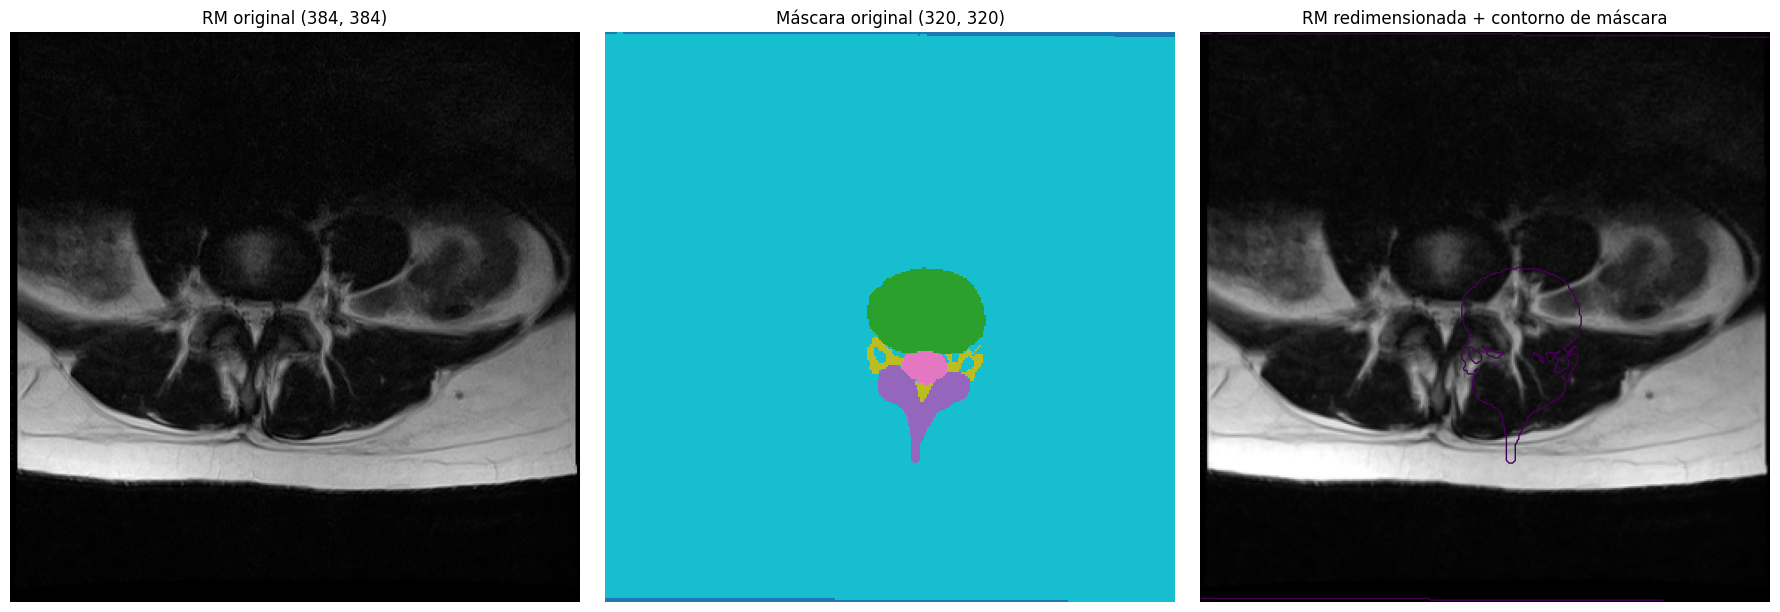

In [41]:
target_slice_id = "slice_cee38610f9057570"

record = next(
    r for r in records
    if r.sliceId == target_slice_id
)

image_raw = as_2d_slice(
    open_medical_array(Path(record.image_path)),
    record.sliceId,
)

mask_raw = as_2d_slice(
    open_medical_array(Path(record.mask_path)),
    record.sliceId,
)

image_on_mask_grid = np.asarray(
    Image.fromarray(
        robust_normalize(image_raw).astype(np.float32)
    ).resize(
        (mask_raw.shape[1], mask_raw.shape[0]),
        resample=Image.Resampling.BILINEAR,
    ),
    dtype=np.float32,
)

foreground_raw = mask_raw != 250

print("Paciente:", record.patientId)
print("Estudio:", record.studyId)
print("Split:", record.split)
print("Imagen:", record.image_path)
print("Máscara:", record.mask_path)
print("Shape imagen:", image_raw.shape)
print("Shape máscara:", mask_raw.shape)
print("Labels:", sorted(int(v) for v in np.unique(mask_raw)))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_raw, cmap="gray")
axes[0].set_title(f"RM original {image_raw.shape}")
axes[0].axis("off")

axes[1].imshow(mask_raw, cmap="tab10", interpolation="nearest")
axes[1].set_title(f"Máscara original {mask_raw.shape}")
axes[1].axis("off")

axes[2].imshow(image_on_mask_grid, cmap="gray")
axes[2].contour(
    foreground_raw.astype(np.uint8),
    levels=[0.5],
    linewidths=1,
)
axes[2].set_title("RM redimensionada + contorno de máscara")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [42]:
import SimpleITK as sitk


def print_medical_geometry(path: str) -> None:
    medical_image = sitk.ReadImage(path)

    print("Archivo:", path)
    print("Dimensión:", medical_image.GetDimension())
    print("Size:", medical_image.GetSize())
    print("Spacing:", medical_image.GetSpacing())
    print("Origin:", medical_image.GetOrigin())
    print("Direction:", medical_image.GetDirection())

    physical_extent = tuple(
        (size - 1) * spacing
        for size, spacing in zip(
            medical_image.GetSize(),
            medical_image.GetSpacing(),
        )
    )

    print("Extensión física aproximada:", physical_extent)
    print()


print_medical_geometry(record.image_path)
print_medical_geometry(record.mask_path)

Archivo: /content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/main_dataset__MRI_Data/01_MRI_Data/0056/L-SPINE_LSS_20160312_135259_693000/T2_TSE_TRA_384_0007/T2_TSE_TRA__0056_002.ima
Dimensión: 3
Size: (384, 384, 1)
Spacing: (0.57291668653488, 0.57291668653488, 4.4)
Origin: (-110.53918053006, -41.223239215047, -39.353089364649)
Direction: (0.9999999886897526, 1.6736800000014256e-09, -0.0001504011127802961, -2.3527814804993174e-05, 0.9876901896191028, -0.15642278854637134, 0.00014854944179920198, 0.15642279031580042, 0.9876901784481218)
Extensión física aproximada: (219.42709094285905, 219.42709094285905, 0.0)

Archivo: /content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0056_D3.png
Dimensión: 2
Size: (320, 320)
Spacing: (1.0, 1.0)
Origin: (0.0, 0.0)
Direction: (1.0, 0.0, 0.0, 1.0)
Extensión física aproximada: (319.0, 319.0)



In [43]:
all_records_for_border_audit = build_records_from_split_manifest()

all_border_rows = []

for index, record in enumerate(all_records_for_border_audit, start=1):
    mask = as_2d_slice(
        open_medical_array(Path(record.mask_path)),
        record.sliceId,
    )

    border = np.concatenate(
        [
            mask[0, :],
            mask[-1, :],
            mask[1:-1, 0],
            mask[1:-1, -1],
        ]
    )

    non_background = border[border != 250]
    labels, counts = np.unique(
        non_background,
        return_counts=True,
    )

    if non_background.size > 0:
        all_border_rows.append(
            {
                "sliceId": record.sliceId,
                "patientId": record.patientId,
                "studyId": record.studyId,
                "split": record.split,
                "imageShape": tuple(
                    as_2d_slice(
                        open_medical_array(Path(record.image_path)),
                        record.sliceId,
                    ).shape
                ),
                "maskShape": tuple(mask.shape),
                "nonBackgroundBorderPixels": int(
                    non_background.size
                ),
                "borderLabels": {
                    int(label): int(count)
                    for label, count in zip(labels, counts)
                },
                "sourceImage": record.sourceImage,
                "sourceMask": record.sourceMask,
            }
        )

    if index % 100 == 0:
        print(f"Auditados: {index}/{len(all_records_for_border_audit)}")

all_border_df = pd.DataFrame(all_border_rows)

print("Máscaras con foreground en el borde:", len(all_border_df))

if not all_border_df.empty:
    display(
        all_border_df.sort_values(
            "nonBackgroundBorderPixels",
            ascending=False,
        )
    )

    print("\nResumen por paciente:")
    display(
        all_border_df.groupby(
            ["patientId", "split"]
        )
        .agg(
            masks=("sliceId", "count"),
            borderPixels=(
                "nonBackgroundBorderPixels",
                "sum",
            ),
        )
        .reset_index()
    )

Auditados: 100/610
Auditados: 200/610
Auditados: 300/610
Auditados: 400/610
Auditados: 500/610
Auditados: 600/610
Máscaras con foreground en el borde: 109


,sliceId,patientId,studyId,split,imageShape,maskShape,nonBackgroundBorderPixels,borderLabels,sourceImage,sourceMask
9,slice_7167e2053b8354c5,23,23,train,"(320, 320)","(320, 320)",1276,{0: 1276},T2_TSE_TRA__0023_003.ima,L1_0023_D3.png
22,slice_ff0e848ac5566454,55,55,test,"(320, 320)","(320, 320)",1276,{0: 1276},T2_TSE_TRA__0055_011.ima,L1_0055_D3.png
23,slice_5960f1986e1580a2,55,55,test,"(320, 320)","(320, 320)",1276,{0: 1276},T2_TSE_TRA__0055_012.ima,L1_0055_D3.png
18,slice_c83cc22470847a9f,33,33,test,"(320, 320)","(320, 320)",1276,{0: 1276},T2_TSE_TRA__0033_012.ima,L1_0033_D5.png
16,slice_7eee4c350dd80d25,33,33,test,"(320, 320)","(320, 320)",1276,{0: 1276},T2_TSE_TRA__0033_003.ima,L1_0033_D3.png
...,...,...,...,...,...,...,...,...,...,...
96,slice_081fdc29ff438473,195,195,train,"(320, 320)","(320, 320)",175,{0: 175},T2_TSE_TRA__0195_014.ima,L1_0195_D4.png
102,slice_8ecffa23025a8e71,198,198,train,"(320, 320)","(320, 320)",175,{0: 175},T2_TSE_TRA__0198_015.ima,L1_0198_D4.png
103,slice_6cc6987b5167f147,198,198,train,"(320, 320)","(320, 320)",175,{0: 175},T2_TSE_TRA__0198_016.ima,L1_0198_D4.png
4,slice_f7e5d45d3225b293,21,21,test,"(320, 320)","(320, 320)",119,{0: 119},T2_TSE_TRA__0021_008.ima,L1_0021_D4.png



Resumen por paciente:


,patientId,split,masks,borderPixels
0,108,test,2,718
1,109,train,2,1131
2,118,val,2,1365
3,126,test,2,895
4,134,train,1,583
5,140,train,2,640
6,149,train,1,533
7,151,train,1,583
8,157,test,3,1872
9,162,val,3,1030


In [44]:
KNOWN_CORRUPT_SOURCE_PAIRS = {
    (
        "56",
        "T2_TSE_TRA__0056_002.ima",
        "L1_0056_D3.png",
    ),
    (
        "56",
        "T2_TSE_TRA__0056_006.ima",
        "L1_0056_D4.png",
    ),
    (
        "56",
        "T2_TSE_TRA__0056_011.ima",
        "L1_0056_D5.png",
    ),
}


def filter_known_corrupt_records(
    records: list[AxialRecord],
) -> tuple[list[AxialRecord], list[dict[str, Any]]]:

    included: list[AxialRecord] = []
    excluded: list[dict[str, Any]] = []

    for record in records:
        source_key = (
            str(record.patientId),
            record.sourceImage,
            record.sourceMask,
        )

        if source_key in KNOWN_CORRUPT_SOURCE_PAIRS:
            excluded.append(
                {
                    **dataclasses.asdict(record),
                    "exclusionReason": (
                        "image_mask_shape_mismatch_384x384_vs_320x320_"
                        "with_raw0_border_artifact"
                    ),
                }
            )
        else:
            included.append(record)

    if len(excluded) != 6:
        raise ValueError(
            "La exclusión curada esperaba exactamente 6 registros, "
            f"pero encontró {len(excluded)}. "
            "Revisar manifest y paths antes de continuar."
        )

    atomic_write_csv(
        OUTPUT_DIRS["manifests"]
        / "excluded_corrupt_axial_records.csv",
        excluded,
    )

    return included, excluded

In [45]:
def select_preflight_examples(records: list[AxialRecord], label_report: dict[str, Any]) -> list[AxialRecord]:
    selected: list[AxialRecord] = []
    for split, limit in [("train", 5), ("val", 3), ("test", 3)]:
        selected.extend([r for r in records if r.split == split][:limit])
    raw0_record = None
    for record in records:
        mask = as_2d_slice(open_medical_array(Path(record.mask_path)), record.sliceId)
        if 0 in {int(v) for v in np.unique(mask)}:
            raw0_record = record
            break
    if raw0_record and raw0_record not in selected:
        selected.append(raw0_record)
    return selected


def render_ground_truth_overlay(records: list[AxialRecord], label_report: dict[str, Any]) -> Path:
    examples = select_preflight_examples(records, label_report)
    figure_path = OUTPUT_DIRS["figures"] / "preflight_ground_truth_overlay.png"
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(len(examples), 2, figsize=(9, max(3, 2.2 * len(examples))))
    if len(examples) == 1:
        axes = np.asarray([axes])
    for row, record in enumerate(examples):
        image = resize_image(robust_normalize(as_2d_slice(open_medical_array(Path(record.image_path)), record.sliceId)))
        mask = apply_label_mapping(resize_mask(as_2d_slice(open_medical_array(Path(record.mask_path)), record.sliceId)), record.sliceId)
        present = [CLASS_INDEX_TO_NAME[int(v)] for v in np.unique(mask)]
        axes[row, 0].imshow(image, cmap="gray")
        axes[row, 0].set_title(f"{record.split} | patientId={record.patientId} | sliceId={record.sliceId}")
        axes[row, 0].axis("off")
        axes[row, 1].imshow(image, cmap="gray")
        axes[row, 1].imshow(mask, cmap="tab10", alpha=0.45, interpolation="nearest", vmin=0, vmax=CFG.NUM_CLASSES - 1)
        axes[row, 1].set_title(f"studyId={record.studyId} | clases={','.join(present)}")
        axes[row, 1].axis("off")
    fig.suptitle("Preflight GT overlay - raw labels: background_250, raw_0, raw_50, raw_100, raw_150, raw_200")
    fig.tight_layout()
    fig.savefig(figure_path, dpi=150)
    plt.close(fig)
    return figure_path


def preflight() -> dict[str, Any]:
    mkdirs_for_run()
    all_records = build_records_from_split_manifest()
    records, excluded_records = filter_known_corrupt_records(all_records)
    split_snapshot_path = save_split_snapshot(records)
    print(summarize_records(records))
    split_integrity = validate_split_integrity(records)
    label_report = scan_labels_and_shapes(records)
    duplicate_report = validate_no_duplicate_leakage(compute_duplicate_report(records, full_hash=True))
    weight_report = class_weight_report(records)
    loaders = build_loaders(records, smoke=True)
    batch = next(iter(loaders["train"]))
    model = build_model().to(DEVICE)
    with torch.inference_mode():
        output = model(batch["image"].to(DEVICE))
    if list(output.shape) != [batch["image"].shape[0], CFG.NUM_CLASSES, *CFG.TARGET_SIZE]:
        raise ValueError(f"Forward shape invalida: {list(output.shape)}")
    overlay_path = render_ground_truth_overlay(records, label_report)
    report = {
        "passed": True,
        "rows": len(records),
        "patientsBySplit": split_integrity["patientsBySplit"],
        "imagesBySplit": split_integrity["imagesBySplit"],
        "classDistributionBySplit": label_report["casePresenceBySplit"],
        "pixelCountsByClass": label_report["pixelCountsBySplit"],
        "missingPaths": [],
        "duplicatesDetected": duplicate_report,
        "leakageCheck": split_integrity,
        "forwardPass": {"shape": list(output.shape), "finite": bool(torch.isfinite(output).all())},
        "labelWarnings": label_report.get("warnings", []),
        "classWeightReport": weight_report,
        "preprocessing": PREPROCESSING_CONFIG,
        "splitSnapshot": split_snapshot_path.name,
        "overlayFigure": overlay_path.name,
        "humanReviewRequired": humanReviewRequired,
        "notClinicalDiagnosis": notClinicalDiagnosis,
        "shapeMismatchCount": label_report.get("shapeMismatchCount",0,),
        "shapeMismatches": label_report.get("shapeMismatches",[],),
        "shapeWarnings": label_report.get("shapeWarnings",[],),
        "excludedCorruptRecordCount": len(excluded_records),
        "excludedCorruptRecords": excluded_records,
        }
    atomic_write_json(OUTPUT_DIRS["reports"] / "preflight_report.json", report)
    atomic_write_json(OUTPUT_DIRS["metrics"] / "dataset_integrity_report.json", report)
    atomic_write_json(OUTPUT_DIRS["metrics"] / "split_integrity_report.json", split_integrity)
    atomic_write_json(OUTPUT_DIRS["models"] / "preprocessing.json", PREPROCESSING_CONFIG)
    return report


PREFLIGHT_REPORT = preflight()
TRAINING_RESULT = TEST_RESULT = QUALITY_GATE_RESULT = None

if CFG.RUN_MODE in {"smoke", "full"}:
    all_records = build_records_from_split_manifest()
    TRAINING_RESULT = train_model(all_records, smoke_only=CFG.RUN_MODE == "smoke")
    if CFG.RUN_MODE == "full":
        TEST_RESULT = evaluate_test_once(all_records)
        QUALITY_GATE_RESULT = quality_gate(TEST_RESULT, {"patientHeldout": True})
        runtime_name = "axial_t2_alkafri_final_best.pt" if QUALITY_GATE_RESULT["qualityGatePassed"] else "axial_t2_alkafri_final_candidate.pt"
        runtime_path = OUTPUT_DIRS["models"] / runtime_name
        save_checkpoint(runtime_path,runtime_artifact_payload(RESUME_DIR / "axial_t2_alkafri_final.best_checkpoint.pt",QUALITY_GATE_RESULT,),)
        model_manifest = generate_manifest_and_model_card(runtime_path, TEST_RESULT, QUALITY_GATE_RESULT)
        example = next(iter(build_loaders(all_records, smoke=True)["test"]))["image"][:1]
        round_trip_model_from_manifest(runtime_path, model_manifest, example)

print(json.dumps({"preflight": PREFLIGHT_REPORT, "training": TRAINING_RESULT, "test": TEST_RESULT, "quality": QUALITY_GATE_RESULT}, indent=2, default=str))


ValueError: La exclusión curada esperaba exactamente 6 registros, pero encontró 9. Revisar manifest y paths antes de continuar.

## Visualizaciones y salidas planificadas

Durante la ejecucion se pueden generar distribucion de clases por split, curvas train/val, Dice por clase, IoU por clase, matriz de confusion y ejemplos deterministas de input/GT/prediccion/overlay.
Los ejemplos deben incluir casos medianos, peores, con `raw_0` y sin `raw_0`, siempre con IDs tecnicos desidentificados.
